In [1]:
from pathlib import Path

DATA_FOLDER = Path("data")
IMAGES_FOLDER = DATA_FOLDER.joinpath(Path("img_align_celeba_reduced")) 

EXAMPLE_PIC = IMAGES_FOLDER.joinpath(Path('000519.jpg'))

TRAINING_SAMPLES = 10000
VALIDATION_SAMPLES = 1000
TEST_SAMPLES = 1000
IMG_WIDTH = 64
IMG_HEIGHT = 64
BATCH_SIZE = 16
NUM_EPOCHS = 10

In [2]:
import pandas as pd



df_attr = pd.read_csv(DATA_FOLDER.joinpath('list_attr_celeba.csv'))
df_attr.set_index('image_id', inplace=True)
print("original CelebA dataset size: ")
df_attr.shape

original CelebA dataset size: 


(202599, 40)

In [3]:
print("available dataset features: ")
df_attr.columns.tolist()

available dataset features: 


['5_o_Clock_Shadow',
 'Arched_Eyebrows',
 'Attractive',
 'Bags_Under_Eyes',
 'Bald',
 'Bangs',
 'Big_Lips',
 'Big_Nose',
 'Black_Hair',
 'Blond_Hair',
 'Blurry',
 'Brown_Hair',
 'Bushy_Eyebrows',
 'Chubby',
 'Double_Chin',
 'Eyeglasses',
 'Goatee',
 'Gray_Hair',
 'Heavy_Makeup',
 'High_Cheekbones',
 'Male',
 'Mouth_Slightly_Open',
 'Mustache',
 'Narrow_Eyes',
 'No_Beard',
 'Oval_Face',
 'Pale_Skin',
 'Pointy_Nose',
 'Receding_Hairline',
 'Rosy_Cheeks',
 'Sideburns',
 'Smiling',
 'Straight_Hair',
 'Wavy_Hair',
 'Wearing_Earrings',
 'Wearing_Hat',
 'Wearing_Lipstick',
 'Wearing_Necklace',
 'Wearing_Necktie',
 'Young']

In [4]:
import numpy as np
import cv2    
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from io import BytesIO
import base64

plt.style.use('ggplot')

%matplotlib inline

Some features example of the example picture: 


Smiling       1
Male         -1
Young        -1
Attractive    1
Name: 000519.jpg, dtype: int64

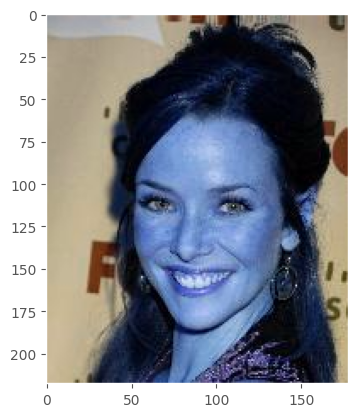

In [5]:
img = cv2.imread(EXAMPLE_PIC)
plt.grid(False)
plt.imshow(img)
print("Some features example of the example picture: ")
df_attr.loc[EXAMPLE_PIC._str.split('/')[-1]][['Smiling','Male','Young', 'Attractive']] #some attributes

since the dataset is reduced, the original csv file of splitting into train-validation-test is no longer valid. 
so we should create our own. 

In [6]:
df_id = pd.read_csv(DATA_FOLDER.joinpath('identity_celeba_reduced.csv'))

df_id.loc[:TRAINING_SAMPLES, "partition"] = 0
df_id.loc[TRAINING_SAMPLES: TRAINING_SAMPLES + VALIDATION_SAMPLES, "partition"] = 1
df_id.loc[TRAINING_SAMPLES + VALIDATION_SAMPLES : TRAINING_SAMPLES + VALIDATION_SAMPLES + TEST_SAMPLES -1, "partition"] = 2

df_partition = df_id.dropna()
df_partition["partition"] = df_partition["partition"].astype(int) 
df_partition.drop(columns=["identity"], inplace=True)
df_partition.rename({"file": "image_id"}, inplace=True, axis=1)

df_partition.to_csv(DATA_FOLDER.joinpath("list_eval_partition_reduced.csv"))

print(" 0 -> training \n 1 -> validation \n 2 -> test") 
df_partition["partition"].value_counts()

 0 -> training 
 1 -> validation 
 2 -> test


partition
0    10000
1     1000
2     1000
Name: count, dtype: int64

In [7]:
df_partition.set_index('image_id', inplace=True)
df_par_attr = df_partition.join(df_attr, how='inner')
df_par_attr.head()

,partition,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000010.jpg,0,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,1,-1,-1,1
000017.jpg,0,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
000021.jpg,0,-1,-1,-1,-1,-1,-1,-1,1,-1,...,-1,1,1,-1,-1,-1,-1,-1,1,-1
000023.jpg,0,1,-1,1,-1,-1,-1,-1,1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
000032.jpg,0,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,1,-1,-1,-1,-1,-1,1,-1


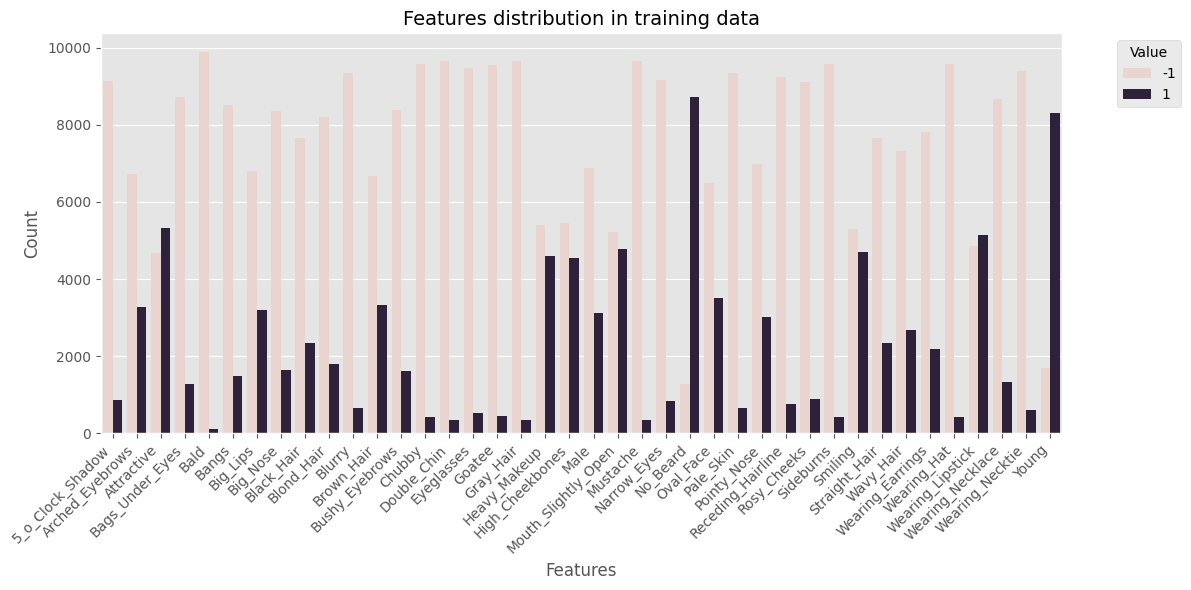

In [8]:
# Get training data
train_data = df_par_attr[df_par_attr["partition"] == 0]

# Melt the dataframe
df_melted = train_data[df_attr.columns].melt(var_name='Feature', value_name='Value')

# Create the plot with hue
plt.figure(figsize=(12, 6))
sns.countplot(x='Feature', hue='Value', data=df_melted)
plt.title('Features distribution in training data', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

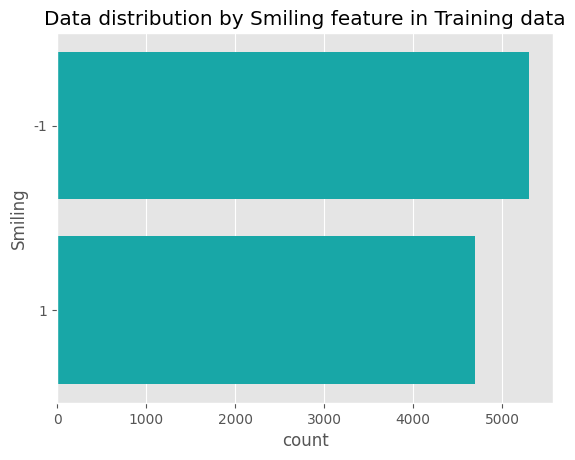

In [9]:
plt.title('Data distribution by Smiling feature in Training data')
sns.countplot(y='Smiling', data=df_par_attr[df_par_attr["partition"] == 0], color="c")
plt.show()

we can see that our target feature in the classification task is balanced enough in our trainig data, so no handling is needed. 

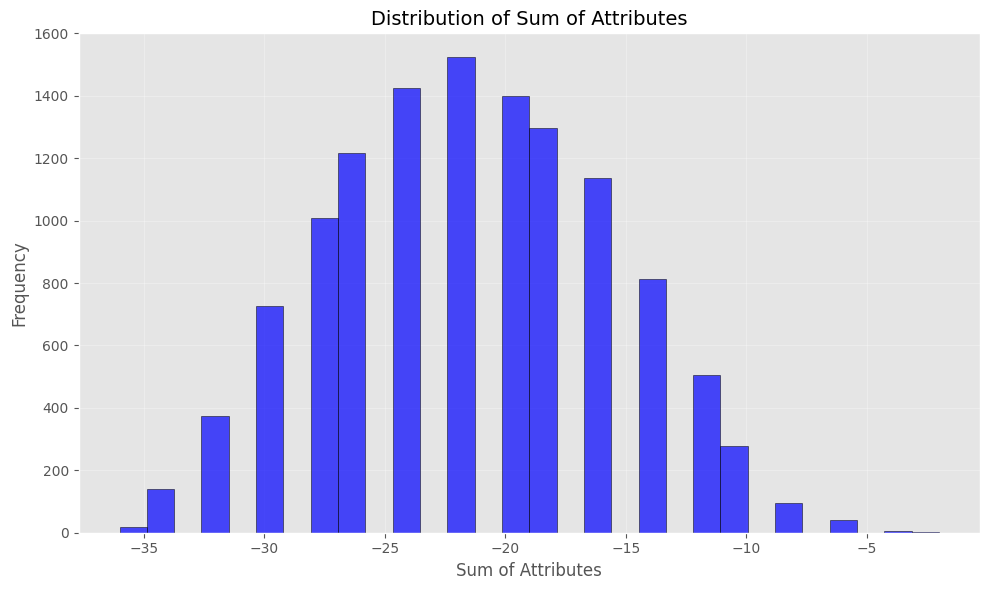

Mean: -21.45
Median: -22.00
Std Dev: 5.82
Min: -36
Max: -2


In [10]:

attribute_sums = df_par_attr[df_attr.columns].sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(attribute_sums, bins=30, color='b', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sum of Attributes', fontsize=14)
plt.xlabel('Sum of Attributes')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean: {attribute_sums.mean():.2f}")
print(f"Median: {attribute_sums.median():.2f}")
print(f"Std Dev: {attribute_sums.std():.2f}")
print(f"Min: {attribute_sums.min()}")
print(f"Max: {attribute_sums.max()}")

In [11]:
print(f"Total features: {len(df_attr.columns)}")

present_counts = (df_par_attr[df_attr.columns] == 1).sum(axis=1)
absent_counts = (df_par_attr[df_attr.columns] == -1).sum(axis=1)

print(f"Average present features: {present_counts.mean():.2f}")
print(f"Average absent features: {absent_counts.mean():.2f}")

Total features: 40
Average present features: 9.27
Average absent features: 30.73


We can see that on average, samples have about **22 more absent features than present features**, which indicates a **highly sparse dataset of vectors**.  

Moreover, the **median is very close to mean**, suggesting a **symmetric distribution of data** which is visible in the historgram.  

All sums are negative, meaning every single sample has more absent features than present ones. 

## Initial hypothesis about the difficulty of tasks:  
the intuitive hypothesis is that the regression task is more difficult than the classification task.  

as the binary classification (Smiling vs Not Smiling) is based on visual characters that are local (the model can only pay attention mostly to the mouth region) and are well defined.  
  

in contrary, the regression task is about predicting a continuous non trivial value (sum of features) which doesn't correspond to a visual direct character nor is concentrated in one region of the picture. 
moreover, the regression task is more sensible to the data distribution, notably in the low density regions (high presence and high absence of features are rare in our data.)   

**NOTE:** the difficulty of regression comes also from the fact that **the target function is more complex and less structured than the frontiere of decision of the binary classification**.   

given this, we are expecting less performance in regression than classification. 


## Covering number and sample complexity:  
We represent each image by its normalized feature vector, so all points lie on the unit hypersphere. Distances between points are bounded in [0, 2]. To compute the covering number, we select several ε values that span this range, including small (0.1–0.3), medium (0.5–1.0), and large (1.5–2.0) values. The medium value, close to the median pairwise distance, provides a reasonable estimate of dataset complexity and allows us to determine a minimal sampling size.

Data representation: 10000 samples, 40 features
Feature space: {(-1, 1)}^40

calculating covering numbers...
ε =  0.10 -> N(A, ε) = 8662
ε =  0.30 -> N(A, ε) = 8662
ε =  0.50 -> N(A, ε) = 8662
ε =  0.70 -> N(A, ε) = 8662
ε =  1.00 -> N(A, ε) = 8662
ε =  1.50 -> N(A, ε) = 8662
ε =  1.70 -> N(A, ε) = 8662
ε =  2.00 -> N(A, ε) = 8662
ε =  2.50 -> N(A, ε) = 6597
ε =  3.00 -> N(A, ε) = 5341
ε =  4.00 -> N(A, ε) = 3154
ε =  5.00 -> N(A, ε) = 1561
ε =  7.00 -> N(A, ε) = 346
ε = 10.00 -> N(A, ε) = 38


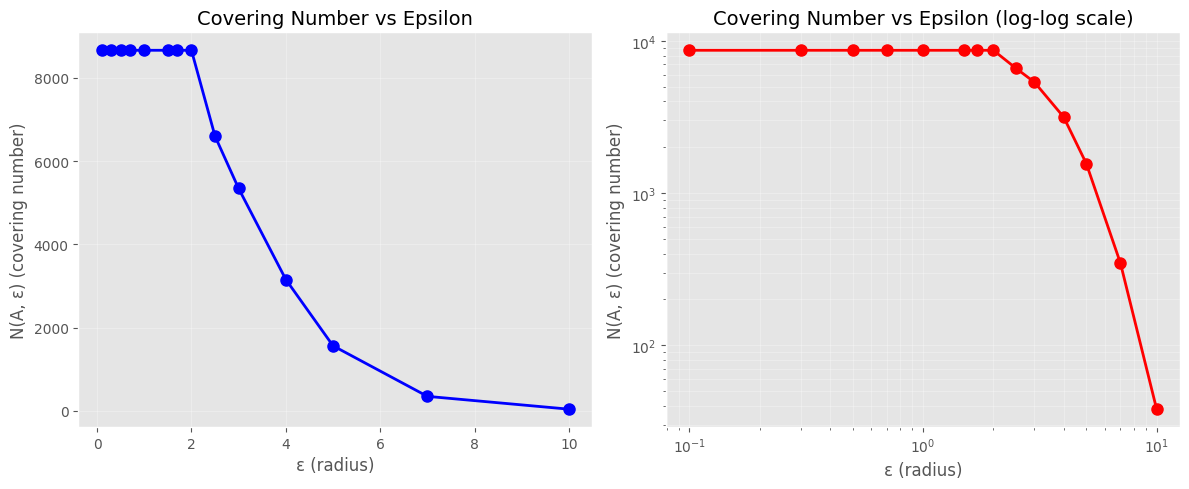


TP1-CN.5: MINIMUM SAMPLING SIZE
Minimum sample size: n ≥ N(A, ε)

ε =  0.10 -> n_min ≈  8662 samples
ε =  0.30 -> n_min ≈  8662 samples
ε =  0.50 -> n_min ≈  8662 samples
ε =  0.70 -> n_min ≈  8662 samples
ε =  1.00 -> n_min ≈  8662 samples
ε =  1.50 -> n_min ≈  8662 samples
ε =  1.70 -> n_min ≈  8662 samples
ε =  2.00 -> n_min ≈  8662 samples
ε =  2.50 -> n_min ≈  6597 samples
ε =  3.00 -> n_min ≈  5341 samples
ε =  4.00 -> n_min ≈  3154 samples
ε =  5.00 -> n_min ≈  1561 samples
ε =  7.00 -> n_min ≈   346 samples
ε = 10.00 -> n_min ≈    38 samples

TP1-CN.6: DATASET SIZE JUSTIFICATION

Actual dataset size: 10000 samples

Analysis for ε = 0.5:
  - Covering number N(A, ε) = 8662
  - Minimum required samples = 8662
  - Actual samples = 10000
  - Ratio: 1.15x the minimum

✓ CONCLUSION: The dataset is SUFFICIENTLY LARGE
  The dataset has 1338 more samples than required



In [13]:
import matplotlib.pyplot as plt
from utils import greedy_epsilon_cover
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
# raw normalized attr features as the vector rep
training_data = df_par_attr[df_par_attr["partition"] == 0]
Z = training_data[df_attr.columns].values
Z_normalized = scaler.fit_transform(Z)

print(f"Data representation: {Z.shape[0]} samples, {Z.shape[1]} features")
print(f"Feature space: {{{-1, 1}}}^{Z.shape[1]}")

epsilon_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 1.7, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0]

#covering numbers for each epsilon
covering_numbers = []
print("\ncalculating covering numbers...")

for eps in epsilon_values:
    N_eps = greedy_epsilon_cover(Z_normalized, eps)
    covering_numbers.append(N_eps)
    print(f"ε = {eps:5.2f} -> N(A, ε) = {N_eps}")

# plot N(A, ε) as a function of ε
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epsilon_values, covering_numbers, 'bo-', linewidth=2, markersize=8)
plt.xlabel('ε (radius)', fontsize=12)
plt.ylabel('N(A, ε) (covering number)', fontsize=12)
plt.title('Covering Number vs Epsilon', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.loglog(epsilon_values, covering_numbers, 'ro-', linewidth=2, markersize=8)
plt.xlabel('ε (radius)', fontsize=12)
plt.ylabel('N(A, ε) (covering number)', fontsize=12)
plt.title('Covering Number vs Epsilon (log-log scale)', fontsize=14)
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# deduce minimum sampling size
print("\n" + "="*70)
print("TP1-CN.5: MINIMUM SAMPLING SIZE")
print("="*70)

print(f"Minimum sample size: n ≥ N(A, ε)")
print()

for eps, N_eps in zip(epsilon_values, covering_numbers):
    min_samples = N_eps
    print(f"ε = {eps:5.2f} -> "
          f"n_min ≈ {int(min_samples):5d} samples")

# justify that dataset is large enough
print("\n" + "="*70)
print("TP1-CN.6: DATASET SIZE JUSTIFICATION")
print("="*70)

actual_size = Z.shape[0]
print(f"\nActual dataset size: {actual_size} samples")
print()

# Choose a reasonable epsilon (e.g., one that gives good coverage)
reasonable_eps_idx = 2 # 0.5
reasonable_eps = epsilon_values[reasonable_eps_idx]
N_reasonable = covering_numbers[reasonable_eps_idx]
min_required = N_reasonable

print(f"Analysis for ε = {reasonable_eps}:")
print(f"  - Covering number N(A, ε) = {N_reasonable}")
print(f"  - Minimum required samples = {min_required}")
print(f"  - Actual samples = {actual_size}")
print(f"  - Ratio: {actual_size / min_required:.2f}x the minimum")
print()

if actual_size >= min_required:
    print(f"✓ CONCLUSION: The dataset is SUFFICIENTLY LARGE")
    print(f"  The dataset has {actual_size - min_required} more samples than required")
else:
    print(f"✗ WARNING: The dataset may be TOO SMALL")
    print(f"  Missing {min_required - actual_size} samples for robust learning")

print()
print("="*70)


## TP1-V.3 à TP1-V.5 : bruit, valeurs atypiques et zones de densité

To complete the exploratory part of TP1, we analyse potential annotation noise proxies, atypical samples, and dense versus sparse regions of the attribute space.


Potential noisy/contradictory samples (proxy): 884
Dense-region threshold (25%): 3.495
Sparse-region threshold (75%): 5.162


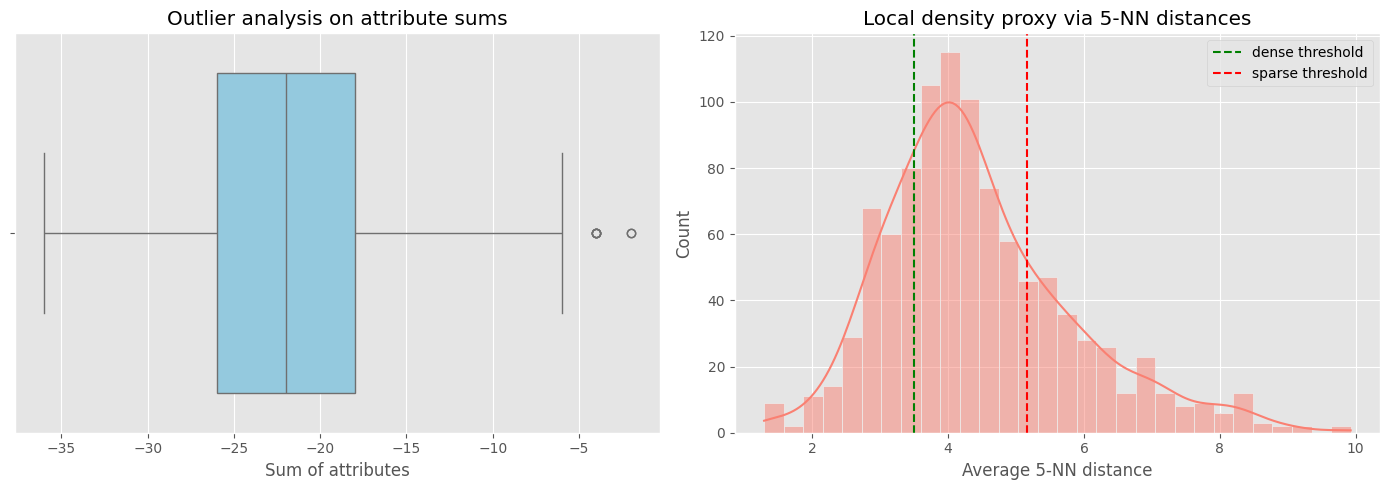

,partition,Smiling,attribute_sum,attribute_sum_zscore,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald
image_id,,,,,,,,,
044363.jpg,0,1,-2,3.332296,-1,1,1,1,-1
063561.jpg,0,1,-2,3.332296,-1,1,1,-1,-1
017469.jpg,0,1,-4,2.989217,-1,1,1,-1,-1
039296.jpg,0,1,-4,2.989217,-1,1,1,-1,-1
024210.jpg,0,1,-4,2.989217,-1,1,1,-1,-1


In [20]:
from sklearn.metrics import pairwise_distances

train_data = df_par_attr[df_par_attr["partition"] == 0].copy()
train_data["attribute_sum"] = train_data[df_attr.columns].sum(axis=1)
train_data["attribute_sum_zscore"] = (train_data["attribute_sum"] - train_data["attribute_sum"].mean()) / (train_data["attribute_sum"].std() + 1e-8)

rare_smiling = train_data[train_data["Smiling"] == 1]["attribute_sum"].quantile(0.05)
rare_not_smiling = train_data[train_data["Smiling"] == -1]["attribute_sum"].quantile(0.95)
potential_noise = train_data[((train_data["Smiling"] == 1) & (train_data["attribute_sum"] <= rare_smiling)) | ((train_data["Smiling"] == -1) & (train_data["attribute_sum"] >= rare_not_smiling))]

outliers = train_data.reindex(train_data["attribute_sum_zscore"].abs().sort_values(ascending=False).head(5).index)

density_sample = train_data.sample(min(1000, len(train_data)), random_state=42)
Z_density = StandardScaler().fit_transform(density_sample[df_attr.columns].values)
distance_matrix = pairwise_distances(Z_density)
np.fill_diagonal(distance_matrix, np.nan)
k = 5
knn_distances = np.nanmean(np.sort(distance_matrix, axis=1)[:, :k], axis=1)
density_sample["knn_distance"] = knn_distances
dense_threshold = np.quantile(knn_distances, 0.25)
sparse_threshold = np.quantile(knn_distances, 0.75)

print(f"Potential noisy/contradictory samples (proxy): {len(potential_noise)}")
print(f"Dense-region threshold (25%): {dense_threshold:.3f}")
print(f"Sparse-region threshold (75%): {sparse_threshold:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=train_data["attribute_sum"], ax=axes[0], color="skyblue")
axes[0].set_title("Outlier analysis on attribute sums")
axes[0].set_xlabel("Sum of attributes")

sns.histplot(knn_distances, bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].axvline(dense_threshold, color="green", linestyle="--", label="dense threshold")
axes[1].axvline(sparse_threshold, color="red", linestyle="--", label="sparse threshold")
axes[1].set_title("Local density proxy via 5-NN distances")
axes[1].set_xlabel("Average 5-NN distance")
axes[1].legend()
plt.tight_layout()
plt.show()

display(outliers[["partition", "Smiling", "attribute_sum", "attribute_sum_zscore"] + list(df_attr.columns[:5])])


### Interpretation

- Samples with extreme attribute sums behave as **atypical observations** and deserve manual inspection.
- The histogram of average 5-nearest-neighbour distances highlights **dense regions** (small local distance) and **sparse regions** (large local distance).
- The `potential_noise` subset is only a **proxy** for suspicious or contradictory labels; it helps us discuss annotation noise without claiming exact errors.


## TP1-G : gradient et optimisation différentiable pour la régression CNN

The regression task is differentiable, so we can optimise the CNN parameters with automatic differentiation and inspect the effect of a gradient-based update.


In [21]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset

from data_loader import create_dataloaders, resolve_default_paths
from experiment_spec import EXPERIMENTAL_FRAME
from train_common import build_model, evaluate_regression, train_one_epoch
from utils import armijo, goldstein, wolfe, plot_multi_losses

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
default_paths = resolve_default_paths()

reg_loaders, reg_sizes = create_dataloaders(
    img_dir=default_paths["image_dir"],
    attr_file=default_paths["attr_file"],
    partition_file=default_paths["partition_file"],
    target_type="regression",
    batch_size=32,
    image_size=64,
    num_workers=0,
    seed=42,
    val_ratio=0.15,
    test_ratio=0.15,
)

print("Regression split sizes:", reg_sizes)
print("Device used for TP1 regression experiments:", device)


Regression split sizes: {'train': 10000, 'val': 1000, 'test': 1000}
Device used for TP1 regression experiments: cpu


In [22]:
criterion_reg = nn.MSELoss()
reg_model = build_model(EXPERIMENTAL_FRAME["models"]["CNN1"], task="regression").to(device)
optimizer_reg = optim.SGD(reg_model.parameters(), lr=1e-3)

inputs_batch, targets_batch = next(iter(reg_loaders["train"]))
inputs_batch = inputs_batch.to(device)
targets_batch = targets_batch.to(device)

reg_model.train()
optimizer_reg.zero_grad()
outputs_before = reg_model(inputs_batch).view(-1)
loss_before = criterion_reg(outputs_before, targets_batch)
loss_before.backward()

gradient_norms = {}
for name, param in reg_model.named_parameters():
    if param.grad is not None:
        gradient_norms[name] = float(param.grad.norm().item())

optimizer_reg.step()
with torch.no_grad():
    outputs_after = reg_model(inputs_batch).view(-1)
    loss_after = criterion_reg(outputs_after, targets_batch)

print(f"Loss before one gradient step: {loss_before.item():.4f}")
print(f"Loss after one gradient step:  {loss_after.item():.4f}")
print("Largest gradient norms:")
display(pd.Series(gradient_norms).sort_values(ascending=False).head(8))


Loss before one gradient step: 510.8034
Loss after one gradient step:  503.5813
Largest gradient norms:


fc1.weight       83.795135
fc_out.bias      43.752567
fc1.bias         16.265936
conv2.weight     11.310184
fc_out.weight     8.890924
conv2.bias        7.630751
conv1.weight      4.843915
conv1.bias        2.463591
dtype: float64

## TP1-LS : line search sur une direction de descente

To stay close to the project, we perform line search on the last regression layer of the CNN for one batch. This illustrates Armijo, Goldstein and Wolfe conditions on a differentiable objective linked to the actual regression task.


In [23]:
selected_params = [reg_model.fc_out.weight, reg_model.fc_out.bias]
selected_shapes = [tuple(param.shape) for param in selected_params]
selected_sizes = [param.numel() for param in selected_params]
theta0 = np.concatenate([param.detach().cpu().numpy().reshape(-1) for param in selected_params]).astype(np.float64)
g0 = np.concatenate([param.grad.detach().cpu().numpy().reshape(-1) for param in selected_params]).astype(np.float64)

def assign_last_layer(theta_np):
    offset = 0
    with torch.no_grad():
        for param, shape, size in zip(selected_params, selected_shapes, selected_sizes):
            values = theta_np[offset: offset + size]
            tensor = torch.tensor(values, dtype=param.dtype, device=param.device).view(shape)
            param.copy_(tensor)
            offset += size

def batch_loss_last_layer(theta_np):
    assign_last_layer(theta_np)
    with torch.no_grad():
        return float(criterion_reg(reg_model(inputs_batch).view(-1), targets_batch).item())

def batch_grad_last_layer(theta_np):
    assign_last_layer(theta_np)
    reg_model.zero_grad()
    loss = criterion_reg(reg_model(inputs_batch).view(-1), targets_batch)
    loss.backward()
    return np.concatenate([param.grad.detach().cpu().numpy().reshape(-1) for param in selected_params]).astype(np.float64)

direction = -g0
armijo_alpha = armijo(batch_loss_last_layer, theta0, direction, g0)
goldstein_alpha = goldstein(batch_loss_last_layer, theta0, direction, g0)
wolfe_alpha = wolfe(batch_loss_last_layer, batch_grad_last_layer, theta0, direction, g0)
assign_last_layer(theta0)

print(f"Armijo step size:    {armijo_alpha:.6f}")
print(f"Goldstein step size: {goldstein_alpha:.6f}")
print(f"Wolfe step size:     {wolfe_alpha:.6f}")


Armijo step size:    0.500000
Goldstein step size: 0.500000
Wolfe step size:     0.500000


## TP1-BV : comparaison biais-variance entre CNN1 et CNN2

We compare both CNN architectures on the regression task using the same reduced training/validation subsets. The train/validation gap helps us discuss underfitting, overfitting, and model complexity.


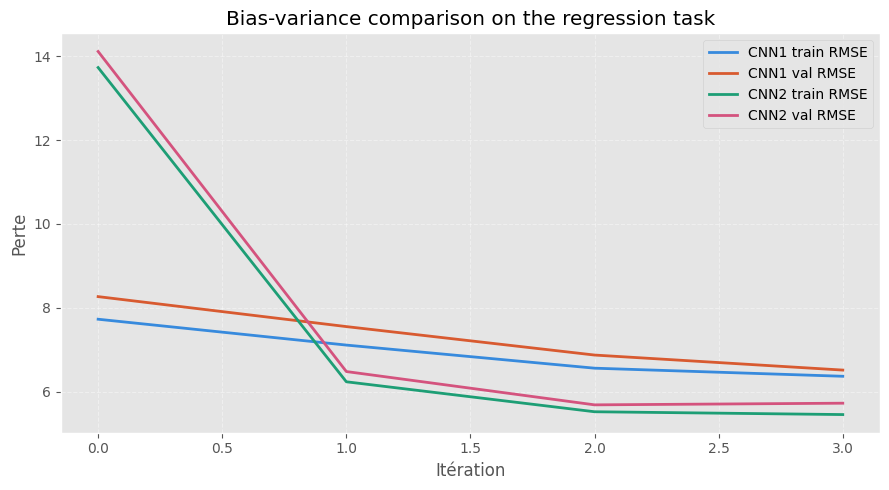

,CNN,Final train RMSE,Final val RMSE,Generalisation gap
0,CNN1,6.372395,6.519912,0.147517
1,CNN2,5.460211,5.731098,0.270886


In [24]:
def make_small_loader(loader, limit, shuffle=False):
    subset_indices = list(range(min(limit, len(loader.dataset))))
    subset = Subset(loader.dataset, subset_indices)
    return DataLoader(subset, batch_size=loader.batch_size, shuffle=shuffle, num_workers=0)

small_train_loader = make_small_loader(reg_loaders["train"], limit=512, shuffle=True)
small_val_loader = make_small_loader(reg_loaders["val"], limit=256, shuffle=False)

def fit_regression_history(model_name, epochs=4, lr=1e-3, weight_decay=0.0):
    model = build_model(model_name, task="regression").to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"train_rmse": [], "val_rmse": []}

    for _ in range(epochs):
        train_one_epoch(model, small_train_loader, criterion, optimizer, device)
        train_metrics = evaluate_regression(model, small_train_loader, criterion, device)
        val_metrics = evaluate_regression(model, small_val_loader, criterion, device)
        history["train_rmse"].append(train_metrics["rmse"])
        history["val_rmse"].append(val_metrics["rmse"])

    return history

cnn1_history = fit_regression_history("simple")
cnn2_history = fit_regression_history("improved")

plot_multi_losses({
    "CNN1 train RMSE": cnn1_history["train_rmse"],
    "CNN1 val RMSE": cnn1_history["val_rmse"],
    "CNN2 train RMSE": cnn2_history["train_rmse"],
    "CNN2 val RMSE": cnn2_history["val_rmse"],
}, title="Bias-variance comparison on the regression task")
plt.show()

bv_summary = pd.DataFrame({
    "CNN": ["CNN1", "CNN2"],
    "Final train RMSE": [cnn1_history["train_rmse"][-1], cnn2_history["train_rmse"][-1]],
    "Final val RMSE": [cnn1_history["val_rmse"][-1], cnn2_history["val_rmse"][-1]],
})
bv_summary["Generalisation gap"] = bv_summary["Final val RMSE"] - bv_summary["Final train RMSE"]
display(bv_summary)


### Bias-variance reading

- A high train and validation error indicates **underfitting**.
- A low train error but clearly higher validation error indicates **overfitting**.
- The preferred complexity is the one that reduces validation error without creating an excessive train/validation gap.


## TP1-REG : validation et régularisation

We already created an explicit train/validation/test split. We now compare different regularisation settings on the regression task to choose a reasonable hyperparameter.


In [25]:
def fit_with_regularisation(weight_decay=0.0, l1_lambda=0.0, epochs=4):
    model = build_model("improved", task="regression").to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for inputs, targets in small_train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).view(-1)
            optimizer.zero_grad()
            outputs = model(inputs).view(-1)
            loss = criterion(outputs, targets)
            if l1_lambda > 0:
                l1_penalty = sum(parameter.abs().sum() for parameter in model.parameters())
                loss = loss + l1_lambda * l1_penalty
            loss.backward()
            optimizer.step()

    train_metrics = evaluate_regression(model, small_train_loader, criterion, device)
    val_metrics = evaluate_regression(model, small_val_loader, criterion, device)
    return train_metrics, val_metrics

regularisation_grid = [
    ("No regularisation", 0.0, 0.0),
    ("L2 = 1e-4", 1e-4, 0.0),
    ("L2 = 1e-3", 1e-3, 0.0),
    ("L1 = 1e-6", 0.0, 1e-6),
]

regularisation_results = []
for label, weight_decay, l1_lambda in regularisation_grid:
    train_metrics, val_metrics = fit_with_regularisation(weight_decay=weight_decay, l1_lambda=l1_lambda)
    regularisation_results.append({
        "Setting": label,
        "Train RMSE": train_metrics["rmse"],
        "Validation RMSE": val_metrics["rmse"],
        "Validation R2": val_metrics["r2"],
    })

regularisation_df = pd.DataFrame(regularisation_results).sort_values("Validation RMSE")
display(regularisation_df)


,Setting,Train RMSE,Validation RMSE,Validation R2
0,No regularisation,5.606619,5.674489,0.088695
3,L1 = 1e-6,5.729584,6.012325,-0.023046
2,L2 = 1e-3,5.876852,6.025927,-0.027680
1,L2 = 1e-4,7.462399,7.837699,-0.738551


## TP1 synthesis

At this stage, TP1 covers:

- visualisation and interpretation of the data,
- sample complexity via covering number,
- differentiable regression loss and one-step gradient update,
- line search on a descent direction,
- bias-variance comparison between CNN1 and CNN2,
- validation and regularisation analysis.

This notebook can therefore serve as the TP1 chapter of the final project, provided the cells are executed and the observations are discussed in the report.
